This notebook allows us to test the previously trained algorithms against different datasets. Before you run the code, you will need the following:

- The .joblib model files from the previous notebook (upload them here).

- The datasets you want to use to test the algorithms.

You also need to pay close attention to the directory paths you provide for both the model files and the datasets. I will point out exactly which lines in the code must be changed if you want to test different algorithms or datasets.


In [4]:
# Spring 2026 Capstone
# William Carroll
# Jessica Brown
# Sydney Halupa

import shutil
from pathlib import Path

UPLOAD_DIR = Path("/home/jupyter/capstone/uploads")          # upload .joblib files here in JupyterLab
MODELS_DIR = Path("/home/jupyter/capstone/testing/models")   # target

UPLOAD_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

moved = []
for p in UPLOAD_DIR.iterdir():
    if p.is_file() and p.suffix.lower() == ".joblib":
        dest = MODELS_DIR / p.name
        shutil.move(str(p), str(dest))
        moved.append(dest.name)

print("Moved:", moved if moved else "(none found)")
print("\nModels dir contents:")
!ls -lah "{MODELS_DIR}"


Moved: ['logreg_tamper_detector_CT.joblib', 'dt_tamper_detector_CT.joblib', 'mantranet_lr_tamper_detector.joblib', 'svm_tamper_detector_CT.joblib', 'knn_tamper_detector_CT.joblib']

Models dir contents:
total 34M
drwxr-xr-x 2 jupyter jupyter 4.0K Feb  9 23:17 .
drwxr-xr-x 3 jupyter jupyter 4.0K Feb  9 23:14 ..
-rw-r--r-- 1 jupyter jupyter  73K Feb  9 23:17 dt_tamper_detector_CT.joblib
-rw-r--r-- 1 jupyter jupyter 1.4M Feb  9 23:17 knn_tamper_detector_CT.joblib
-rw-r--r-- 1 jupyter jupyter 1.7K Feb  9 23:17 logreg_tamper_detector_CT.joblib
-rw-r--r-- 1 jupyter jupyter 1.7K Feb  9 23:17 mantranet_lr_tamper_detector.joblib
-rw-r--r-- 1 jupyter jupyter  32M Feb  9 23:14 rf_tamper_detector_CT.joblib
-rw-r--r-- 1 jupyter jupyter 583K Feb  9 23:17 svm_tamper_detector_CT.joblib


Upload the dataset ZIP file to capstone/uploads, then update DATA_DIR to the destination path where you want the dataset extracted. The dataset should always be placed under:

capstone/testing/datasets/...

Also, make sure you set ZIP_NAME to the exact filename of the ZIP you uploaded; otherwise the code won’t find it and the unzip step will fail.

In [47]:
import zipfile, shutil
from pathlib import Path

DATA_DIR   = Path("capstone/testing/datasets/BTD")
UPLOAD_DIR = Path("capstone/uploads")

# CHANGE THIS to the exact filename you uploaded:
ZIP_NAME = "BTD.zip"

DATA_DIR.mkdir(parents=True, exist_ok=True)

zip_path = UPLOAD_DIR / ZIP_NAME
if not zip_path.exists():
    raise FileNotFoundError(f"{zip_path} not found. Check the filename and uploads folder.")

# Optional: clear DATA_DIR before extracting
for item in DATA_DIR.iterdir():
    if item.is_dir():
        shutil.rmtree(item)
    else:
        item.unlink()

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(DATA_DIR)

print("Extracted", ZIP_NAME, "to:", str(DATA_DIR))

!find "{DATA_DIR}" -maxdepth 3 -type d | head -n 30
!find "{DATA_DIR}" -type f | head -n 20

Extracted BTD.zip to: capstone/testing/datasets/BTD
capstone/testing/datasets/BTD
capstone/testing/datasets/BTD/MRI
capstone/testing/datasets/BTD/MRI/Signa HDxt
capstone/testing/datasets/BTD/MRI/Signa HDxt/Breast_MRI_130
capstone/testing/datasets/BTD/MRI/Signa HDxt/Breast_MRI_162
capstone/testing/datasets/BTD/MRI/Signa HDxt/Breast_MRI_025
capstone/testing/datasets/BTD/MRI/Signa HDxt/Breast_MRI_243
capstone/testing/datasets/BTD/MRI/Signa HDxt/Breast_MRI_151
capstone/testing/datasets/BTD/MRI/Signa HDxt/Breast_MRI_038
capstone/testing/datasets/BTD/MRI/Signa HDxt/Breast_MRI_309
capstone/testing/datasets/BTD/MRI/Avanto
capstone/testing/datasets/BTD/MRI/Avanto/Breast_MRI_153
capstone/testing/datasets/BTD/MRI/Avanto/Breast_MRI_039
capstone/testing/datasets/BTD/MRI/Avanto/Breast_MRI_044
capstone/testing/datasets/BTD/MRI/Avanto/Breast_MRI_526
capstone/testing/datasets/BTD/MRI/Avanto/Breast_MRI_534
capstone/testing/datasets/BTD/MRI/Optima MR450w
capstone/testing/datasets/BTD/MRI/Optima MR450w/Br

The 3rd block allows us to split the dataset into the respective splits. The code should be able to distinguish between tampered and untampered datasets, but please double-check the output if it throws any errors. There’s a chance something might not work and we would need to add a detector to identify the dataset’s folder format (since some datasets are set up inconsistently, and no two are structured the same way).

In [44]:
import os, shutil
import pandas as pd
from glob import glob
from sklearn.model_selection import train_test_split

# =========================
# CHANGE THESE TWO LINES
# =========================
BASE_DIR = "capstone/testing/datasets/COVID_Tampered/3bzv6t24ts-1/COVID-19 Digital X-rays Forgery Dataset/9classes"
OUT_DIR  = "capstone/testing/splits/COVID_Tampered_split"
# =========================

RANDOM_SEED = 42
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-9

USE_SYMLINKS = True

IMG_EXTS   = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
DICOM_EXTS = (".dcm",)
NPY_EXTS   = (".npy",)

# helpers
def files_with_exts(root, exts):
    # case-insensitive extension match
    all_files = glob(os.path.join(root, "**", "*"), recursive=True)
    exts_l = tuple(e.lower() for e in exts)
    return sorted([p for p in all_files if os.path.isfile(p) and p.lower().endswith(exts_l)])

def all_data_files(root):
    return (files_with_exts(root, IMG_EXTS) +
            files_with_exts(root, DICOM_EXTS) +
            files_with_exts(root, NPY_EXTS))

def ensure_empty_dir(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)

def safe_link_or_copy(src, dst):
    os.makedirs(os.path.dirname(dst), exist_ok=True)

    if os.path.lexists(dst):
        return

    if USE_SYMLINKS:
        os.symlink(os.path.abspath(src), dst)
    else:
        shutil.copy2(src, dst)


def split_stratified_or_clean_only(df):
    # df must have filepath,label
    if df["label"].nunique() == 1:
        train_df, tmp_df = train_test_split(df, test_size=(1-TRAIN_RATIO), random_state=RANDOM_SEED, shuffle=True)
        val_frac = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
        val_df, test_df = train_test_split(tmp_df, test_size=(1-val_frac), random_state=RANDOM_SEED, shuffle=True)
    else:
        train_df, tmp_df = train_test_split(
            df, test_size=(1-TRAIN_RATIO), random_state=RANDOM_SEED, stratify=df["label"]
        )
        val_frac = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
        val_df, test_df = train_test_split(
            tmp_df, test_size=(1-val_frac), random_state=RANDOM_SEED, stratify=tmp_df["label"]
        )

    train_df = train_df.assign(split="train")
    val_df   = val_df.assign(split="val")
    test_df  = test_df.assign(split="test")
    return pd.concat([train_df, val_df, test_df], ignore_index=True)

def write_split_folders(df, out_dir):
    ensure_empty_dir(out_dir)

    KNOWN_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".dcm", ".npy")

    for i, row in df.iterrows():
        src   = row["filepath"]
        split = row["split"]
        label = int(row["label"])
        cls   = "clean" if label == 0 else "tampered"

        base = os.path.basename(src)

        b = base
        bl = b.lower()
        changed = True
        while changed:
            changed = False
            for ext in KNOWN_EXTS:
                if bl.endswith(ext + ext):
                    b = b[:-len(ext)]
                    bl = b.lower()
                    changed = True
                    break

        out_name = f"{i:08d}_{b}"
        dst = os.path.join(out_dir, split, cls, out_name)
        safe_link_or_copy(src, dst)

    def count_files(p):
        if not os.path.isdir(p):
            return 0

        n = 0
        stack = [p]
        while stack:
            cur = stack.pop()
            try:
                with os.scandir(cur) as it:
                    for entry in it:
                        if entry.is_dir(follow_symlinks=False):
                            stack.append(entry.path)
                        else:
                            name = entry.name.lower()
                            if name.endswith(KNOWN_EXTS):
                                # Count real files and also symlinks (you create symlinks)
                                if entry.is_file(follow_symlinks=False) or entry.is_symlink():
                                    n += 1
            except FileNotFoundError:
                continue

        return n

    print("\nFinal counts:")
    for split in ["train", "val", "test"]:
        for cls in ["clean", "tampered"]:
            p = os.path.join(out_dir, split, cls)
            print(f"{split:5s} {cls:8s}:", count_files(p))



# Detectors
# We had to create multiple detector classes in order to detect the file structure of the selected datasets.
# This is because not every dataset has the same exact structure. If you want to test the models against
# a certain dataset, you will most likely have to create a detector class for that dataset.
def detect_already_split_layout(base_dir):
    # base_dir/{train,val,test}/{clean,tampered}/...
    ok = all(os.path.isdir(os.path.join(base_dir, s)) for s in ["train","val","test"])
    if not ok:
        return None
    rows = []
    for split in ["train","val","test"]:
        for cls, lab in [("clean",0),("tampered",1)]:
            p = os.path.join(base_dir, split, cls)
            if not os.path.isdir(p):
                continue
            # <<< UPDATED: include npy too
            files = all_data_files(p)
            for f in files:
                rows.append({"filepath": f, "label": lab, "split": split})
    if len(rows) == 0:
        return None
    return pd.DataFrame(rows)

def detect_image_tamper_dataset(base_dir):
    # Kaggle "image-tamper-dataset": original + tamper folders
    clean_dir = os.path.join(base_dir, "original")
    tamp_dirs = [os.path.join(base_dir, x) for x in ["copy_move","copy_paste","content_removal","text_addition"]]
    if not os.path.isdir(clean_dir):
        return None
    tamp_dirs = [d for d in tamp_dirs if os.path.isdir(d)]
    if len(tamp_dirs) == 0:
        return None

    clean = all_data_files(clean_dir)
    tamp = []
    for d in tamp_dirs:
        tamp += all_data_files(d)

    if len(clean) == 0 or len(tamp) == 0:
        return None

    df = pd.DataFrame({"filepath": clean + tamp, "label": ([0]*len(clean)) + ([1]*len(tamp))})
    return df

def detect_clean_tampered_folders_anywhere(base_dir):
    # finds any folders named clean and tampered under base_dir
    clean_dirs = [d for d in glob(os.path.join(base_dir, "**", "clean"), recursive=True) if os.path.isdir(d)]
    tamp_dirs  = [d for d in glob(os.path.join(base_dir, "**", "tampered"), recursive=True) if os.path.isdir(d)]
    if len(clean_dirs) == 0 or len(tamp_dirs) == 0:
        return None

    clean, tamp = [], []
    for d in clean_dirs:
        clean += all_data_files(d)
    for d in tamp_dirs:
        tamp  += all_data_files(d)

    if len(clean) == 0 or len(tamp) == 0:
        return None

    df = pd.DataFrame({"filepath": clean + tamp, "label": ([0]*len(clean)) + ([1]*len(tamp))})
    return df

def detect_by_top_folder_rules(base_dir, clean_folders, tampered_prefixes=()):
    # labels by top-level folder name under base_dir
    all_files = all_data_files(base_dir)
    if len(all_files) == 0:
        return None

    clean, tamp = [], []
    for f in all_files:
        rel = os.path.relpath(f, base_dir)
        top = rel.split(os.sep)[0].lower()

        if top in {x.lower() for x in clean_folders}:
            clean.append(f)
        elif any(top.startswith(p.lower()) for p in tampered_prefixes):
            tamp.append(f)

    if len(clean) == 0 or len(tamp) == 0:
        # allow fallback if it's untampered-only
        if len(clean) == 0 and len(tamp) == 0:
            return None
        if len(tamp) == 0 and len(clean) > 0:
            # clean-only dataset
            return pd.DataFrame({"filepath": clean, "label": [0]*len(clean)})
        return None

    return pd.DataFrame({"filepath": clean + tamp, "label": ([0]*len(clean)) + ([1]*len(tamp))})

def detect_untampered_only(base_dir):
    # last resort: treat everything as clean
    all_files = all_data_files(base_dir)
    if len(all_files) == 0:
        return None
    return pd.DataFrame({"filepath": all_files, "label": [0]*len(all_files)})

# BTD DETECTOR
def _find_dir_named_anywhere(root, target_name):
    target = target_name.lower()
    for dirpath, dirnames, _ in os.walk(root):
        for dn in dirnames:
            if dn.lower() == target:
                return os.path.join(dirpath, dn)
    return None

def _find_child_dir_ci(parent, name):
    if not os.path.isdir(parent):
        return None
    target = name.lower()
    for dn in os.listdir(parent):
        p = os.path.join(parent, dn)
        if os.path.isdir(p) and dn.lower() == target:
            return p
    return None

def _collect_files_from_dirs(dirs):
    out = []
    for d in dirs:
        out += all_data_files(d)
    return sorted(set(out))

def _make_df(clean_dirs, tampered_dirs):
    clean_files = _collect_files_from_dirs(clean_dirs)
    tamp_files  = _collect_files_from_dirs(tampered_dirs)
    if len(clean_files) == 0 or len(tamp_files) == 0:
        return None
    return pd.DataFrame({
        "filepath": clean_files + tamp_files,
        "label": ([0]*len(clean_files)) + ([1]*len(tamp_files))
    })

def _find_ct_root_for_btd(base_dir):
    ct0 = _find_child_dir_ci(base_dir, "CT")
    candidates = [ct0] if ct0 else []
    ct_any = _find_dir_named_anywhere(base_dir, "CT")
    if ct_any and ct_any not in candidates:
        candidates.append(ct_any)

    for ct in candidates:
        inj = _find_child_dir_ci(ct, "injection")
        rem = _find_child_dir_ci(ct, "removal")
        if not inj or not rem:
            continue
        if _find_child_dir_ci(inj, "TM") and _find_child_dir_ci(rem, "TB"):
            return ct
    return None

def detect_btd_all(base_dir):
    """
    Returns df(filepath,label) for BTD (clean vs tampered), combining:
      CT injection: TM vs FM_CTGAN, TM vs FM_SD
      CT removal  : TB vs FB_CTGAN, TB vs FB_SD
    """
    ct_root = _find_ct_root_for_btd(base_dir)
    if not ct_root:
        return None

    inj = _find_child_dir_ci(ct_root, "injection")
    rem = _find_child_dir_ci(ct_root, "removal")

    tm = _find_child_dir_ci(inj, "TM")
    fm_ctgan = _find_child_dir_ci(inj, "FM_CTGAN")
    fm_sd    = _find_child_dir_ci(inj, "FM_SD")

    tb = _find_child_dir_ci(rem, "TB")
    fb_ctgan = _find_child_dir_ci(rem, "FB_CTGAN")
    fb_sd    = _find_child_dir_ci(rem, "FB_SD")

    dfs = []
    if tm and fm_ctgan:
        df = _make_df([tm], [fm_ctgan])
        if df is not None: dfs.append(df)
    if tm and fm_sd:
        df = _make_df([tm], [fm_sd])
        if df is not None: dfs.append(df)
    if tb and fb_ctgan:
        df = _make_df([tb], [fb_ctgan])
        if df is not None: dfs.append(df)
    if tb and fb_sd:
        df = _make_df([tb], [fb_sd])
        if df is not None: dfs.append(df)

    if len(dfs) == 0:
        return None

    mri_root = _find_child_dir_ci(base_dir, "MRI") or _find_dir_named_anywhere(base_dir, "MRI")
    print("BTD CT root detected at:", ct_root)
    if mri_root:
        print("BTD MRI root detected at:", mri_root)

    df_all = pd.concat(dfs, ignore_index=True).drop_duplicates(subset=["filepath"]).reset_index(drop=True)
    return df_all

# main
print("BASE_DIR:", BASE_DIR)
print("OUT_DIR :", OUT_DIR)
print("Link mode:", "symlink" if USE_SYMLINKS else "copy")

# Chekcs if the dataset is already split
df0 = detect_already_split_layout(BASE_DIR)
if df0 is not None:
    print("Using existing split layout (no re-splitting). Rows:", len(df0))
    display(df0.head())
    raise SystemExit

# BTD HANDLING
df_btd = detect_btd_all(BASE_DIR)
if df_btd is not None:
    print("Detected BTD rows:", len(df_btd), " label counts:", df_btd["label"].value_counts().to_dict())

    df_split = split_stratified_or_clean_only(df_btd)
    df_split.to_csv(OUT_DIR + "_manifest.csv", index=False)
    print("Saved manifest:", OUT_DIR + "_manifest.csv")

    write_split_folders(df_split, OUT_DIR)
    print("\nDone. Splits ready at:", OUT_DIR)
    raise SystemExit

# Try known tamper datasets
df = detect_image_tamper_dataset(BASE_DIR)
if df is None:
    df = detect_clean_tampered_folders_anywhere(BASE_DIR)

# Optional: add one dataset-specific rule-set here (easy to extend)
# Example: COVID forgery 9classes style:
if df is None:
    df = detect_by_top_folder_rules(
        BASE_DIR,
        clean_folders=["COVID-19", "Normal", "Viral"],
        tampered_prefixes=["F "]  # matches "F CM ...", "F S ..."
    )

# If still nothing: treat as untampered-only
if df is None:
    df = detect_untampered_only(BASE_DIR)
    print("No tamper labels detected. Treating dataset as CLEAN-ONLY.")

print("Detected rows:", len(df), " label counts:", df["label"].value_counts().to_dict())

df_split = split_stratified_or_clean_only(df)
df_split.to_csv(OUT_DIR + "_manifest.csv", index=False)
print("Saved manifest:", OUT_DIR + "_manifest.csv")

write_split_folders(df_split, OUT_DIR)
print("\nDone. Splits ready at:", OUT_DIR)

BASE_DIR: capstone/testing/datasets/COVID_Tampered/3bzv6t24ts-1/COVID-19 Digital X-rays Forgery Dataset/9classes
OUT_DIR : capstone/testing/splits/COVID_Tampered_split
Link mode: symlink
Detected rows: 15540  label counts: {1: 10195, 0: 5345}
Saved manifest: capstone/testing/splits/COVID_Tampered_split_manifest.csv

Final counts:
train clean   : 3741
train tampered: 7136
val   clean   : 802
val   tampered: 1529
test  clean   : 802
test  tampered: 1530

Done. Splits ready at: capstone/testing/splits/COVID_Tampered_split


This block of code allows us to test the algorithms against the dataset splits we made earlier. Here, you will select the model and the dataset you want to test against.


TRAIN -> using 249 clean + 0 tampered


TRAIN CLEAN feature extraction: 100%|██████████| 249/249 [01:16<00:00,  3.25img/s]
TRAIN TAMPERED feature extraction: 0img [00:00, ?img/s]


TRAIN: kept 249 samples, failed-to-load 0

VAL -> using 54 clean + 0 tampered


VAL CLEAN feature extraction: 100%|██████████| 54/54 [00:13<00:00,  3.98img/s]
VAL TAMPERED feature extraction: 0img [00:00, ?img/s]


VAL: kept 54 samples, failed-to-load 0

TEST -> using 54 clean + 0 tampered


TEST CLEAN feature extraction: 100%|██████████| 54/54 [00:17<00:00,  3.15img/s]
TEST TAMPERED feature extraction: 0img [00:00, ?img/s]


TEST: kept 54 samples, failed-to-load 0

Shapes: train (249, 12) (249,) | val (54, 12) (54,) | test (54, 12) (54,)

Loaded model: capstone/testing/models/svm_tamper_detector_CT.joblib
Model expects n_features: 12

RUN 1/5

=== TRAIN ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[ 74 175]
 [  0   0]]
False Positive Rate (pred tampered on clean-only): 0.7028
Specificity / TNR (pred clean on clean-only): 0.2972

=== VALIDATION ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[18 36]
 [ 0  0]]
False Positive Rate (pred tampered on clean-only): 0.6667
Specificity / TNR (pred clean on clean-only): 0.3333

=== TEST ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[18 36]
 [ 0  0]]
False Positive Rate (pred tampered on clean-only): 0.6667
Specificity / TNR (pred clean on clean-only): 0.3333


,Split,Accuracy,False Positive Rate,Specificity (TNR),TN,FP,FN,TP,N_Clean,N_Tampered
0,Train,0.2972,0.7028,0.2972,74,175,0,0,249,0
1,Validation,0.3333,0.6667,0.3333,18,36,0,0,54,0
2,Test,0.3333,0.6667,0.3333,18,36,0,0,54,0


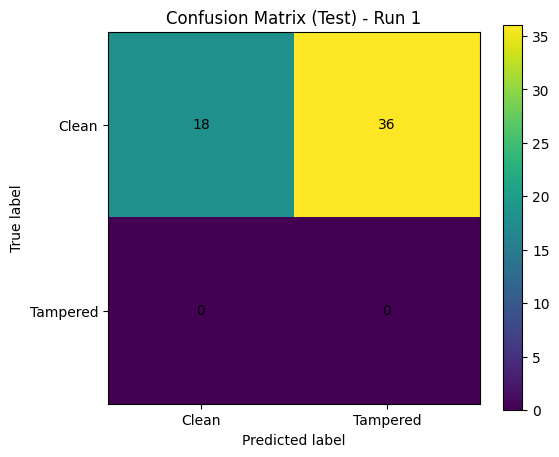


RUN 2/5

=== TRAIN ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[ 74 175]
 [  0   0]]
False Positive Rate (pred tampered on clean-only): 0.7028
Specificity / TNR (pred clean on clean-only): 0.2972

=== VALIDATION ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[18 36]
 [ 0  0]]
False Positive Rate (pred tampered on clean-only): 0.6667
Specificity / TNR (pred clean on clean-only): 0.3333

=== TEST ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[18 36]
 [ 0  0]]
False Positive Rate (pred tampered on clean-only): 0.6667
Specificity / TNR (pred clean on clean-only): 0.3333


,Split,Accuracy,False Positive Rate,Specificity (TNR),TN,FP,FN,TP,N_Clean,N_Tampered
0,Train,0.2972,0.7028,0.2972,74,175,0,0,249,0
1,Validation,0.3333,0.6667,0.3333,18,36,0,0,54,0
2,Test,0.3333,0.6667,0.3333,18,36,0,0,54,0


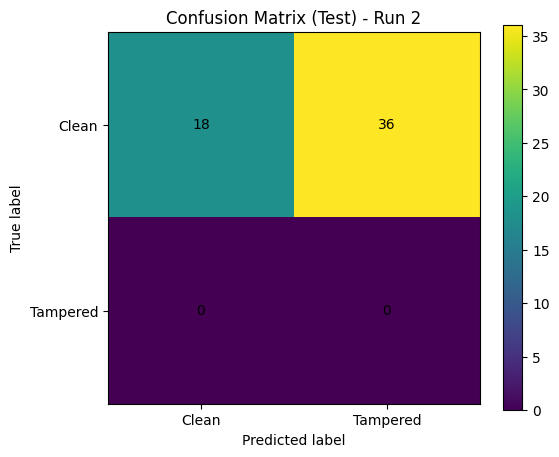


RUN 3/5

=== TRAIN ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[ 74 175]
 [  0   0]]
False Positive Rate (pred tampered on clean-only): 0.7028
Specificity / TNR (pred clean on clean-only): 0.2972

=== VALIDATION ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[18 36]
 [ 0  0]]
False Positive Rate (pred tampered on clean-only): 0.6667
Specificity / TNR (pred clean on clean-only): 0.3333

=== TEST ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[18 36]
 [ 0  0]]
False Positive Rate (pred tampered on clean-only): 0.6667
Specificity / TNR (pred clean on clean-only): 0.3333


,Split,Accuracy,False Positive Rate,Specificity (TNR),TN,FP,FN,TP,N_Clean,N_Tampered
0,Train,0.2972,0.7028,0.2972,74,175,0,0,249,0
1,Validation,0.3333,0.6667,0.3333,18,36,0,0,54,0
2,Test,0.3333,0.6667,0.3333,18,36,0,0,54,0


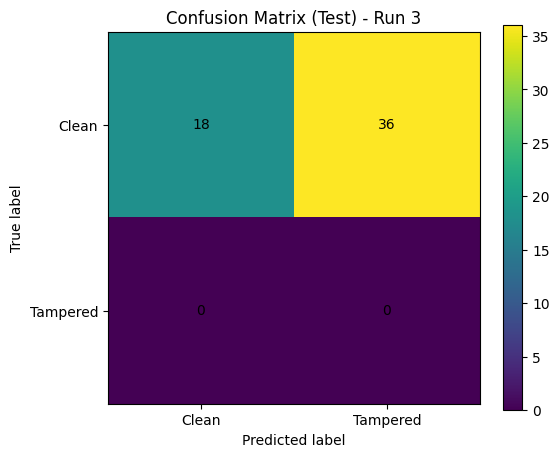


RUN 4/5

=== TRAIN ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[ 74 175]
 [  0   0]]
False Positive Rate (pred tampered on clean-only): 0.7028
Specificity / TNR (pred clean on clean-only): 0.2972

=== VALIDATION ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[18 36]
 [ 0  0]]
False Positive Rate (pred tampered on clean-only): 0.6667
Specificity / TNR (pred clean on clean-only): 0.3333

=== TEST ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[18 36]
 [ 0  0]]
False Positive Rate (pred tampered on clean-only): 0.6667
Specificity / TNR (pred clean on clean-only): 0.3333


,Split,Accuracy,False Positive Rate,Specificity (TNR),TN,FP,FN,TP,N_Clean,N_Tampered
0,Train,0.2972,0.7028,0.2972,74,175,0,0,249,0
1,Validation,0.3333,0.6667,0.3333,18,36,0,0,54,0
2,Test,0.3333,0.6667,0.3333,18,36,0,0,54,0


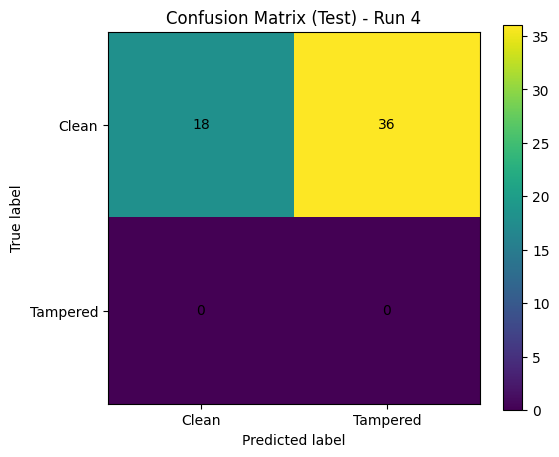


RUN 5/5

=== TRAIN ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[ 74 175]
 [  0   0]]
False Positive Rate (pred tampered on clean-only): 0.7028
Specificity / TNR (pred clean on clean-only): 0.2972

=== VALIDATION ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[18 36]
 [ 0  0]]
False Positive Rate (pred tampered on clean-only): 0.6667
Specificity / TNR (pred clean on clean-only): 0.3333

=== TEST ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[18 36]
 [ 0  0]]
False Positive Rate (pred tampered on clean-only): 0.6667
Specificity / TNR (pred clean on clean-only): 0.3333


,Split,Accuracy,False Positive Rate,Specificity (TNR),TN,FP,FN,TP,N_Clean,N_Tampered
0,Train,0.2972,0.7028,0.2972,74,175,0,0,249,0
1,Validation,0.3333,0.6667,0.3333,18,36,0,0,54,0
2,Test,0.3333,0.6667,0.3333,18,36,0,0,54,0


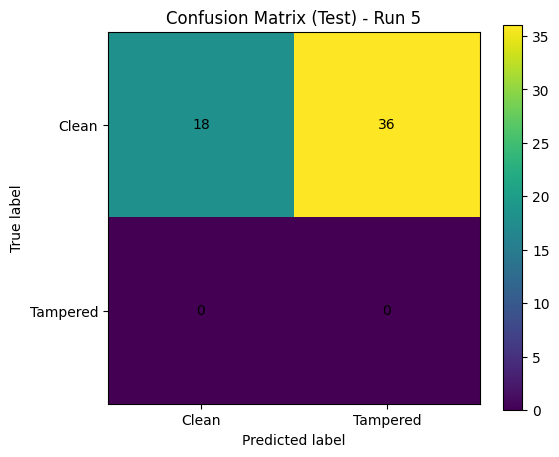


AGGREGATED RESULTS ACROSS RUNS


,Split (Mean),Accuracy,False Positive Rate,Specificity (TNR),TN,FP,FN,TP,N_Clean,N_Tampered
0,Test,0.3333,0.6667,0.3333,18.0,36.0,0.0,0.0,54.0,0.0
1,Train,0.2972,0.7028,0.2972,74.0,175.0,0.0,0.0,249.0,0.0
2,Validation,0.3333,0.6667,0.3333,18.0,36.0,0.0,0.0,54.0,0.0


,Split (Std),Accuracy,False Positive Rate,Specificity (TNR),TN,FP,FN,TP,N_Clean,N_Tampered
0,Test,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Train,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Validation,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



AVERAGED CONFUSION MATRIX (TEST) ACROSS RUNS

Average CM (Counts): [[TN FP],[FN TP]]
[[18. 36.]
 [ 0.  0.]]

Average CM (Row-normalized rates): [[TN_rate FP_rate],[FN_rate TP_rate]]
[[0.33333333 0.66666667]
 [0.         0.        ]]


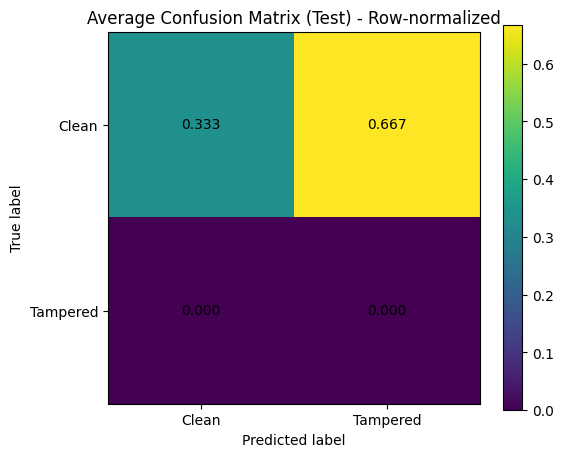

In [1]:
!pip -q install scikit-learn scikit-image opencv-python numpy joblib tqdm pandas pydicom matplotlib
!pip -q install pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg gdcm

import os
import numpy as np
import cv2
import joblib
import pandas as pd
from glob import glob
from tqdm import tqdm
import pydicom

from skimage.feature import graycomatrix, graycoprops
from skimage.measure import shannon_entropy

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

# ==========================================
# CHANGE THESE TWO LINES
# ==========================================
TAMPER_SPLIT_DIR = "capstone/testing/splits/COVID_Untampered_split"
MODEL_PATH       = "capstone/testing/models/svm_tamper_detector_CT.joblib"
# ==========================================

N_FEATS = 12

# Unified loader (DICOM + images + NPY) with CT-style normalization
def load_u8_any(path: str, target_size=None):
    ext = os.path.splitext(path)[1].lower()

    # NPY path
    if ext == ".npy":
        try:
            arr = np.load(path)
        except Exception:
            return None

        img = np.squeeze(arr)

        # Handle (H,W,1)/(H,W,3) or (1,H,W)/(3,H,W)
        if img.ndim == 3 and img.shape[-1] in (1, 3):
            if img.shape[-1] == 3:
                img = cv2.cvtColor(img.astype(np.float32), cv2.COLOR_BGR2GRAY)
            else:
                img = img[..., 0]
        elif img.ndim == 3 and img.shape[0] in (1, 3):
            if img.shape[0] == 3:
                img = np.transpose(img, (1, 2, 0))
                img = cv2.cvtColor(img.astype(np.float32), cv2.COLOR_BGR2GRAY)
            else:
                img = img[0, :, :]

        if img.ndim != 2:
            return None

        img = img.astype(np.float32)

    # DICOM path
    elif ext == ".dcm":
        try:
            ds = pydicom.dcmread(path, force=True)
            if not hasattr(ds, "PixelData"):
                return None

            img = ds.pixel_array.astype(np.float32)

            # If multi-frame, take first frame
            if img.ndim == 3:
                img = img[0]

            # Handle MONOCHROME1 inversion
            phot = str(getattr(ds, "PhotometricInterpretation", "")).upper()
            if phot == "MONOCHROME1":
                img = img.max() - img

            slope = float(getattr(ds, "RescaleSlope", 1.0))
            intercept = float(getattr(ds, "RescaleIntercept", 0.0))
            img = img * slope + intercept

        except Exception:
            return None

    # Normal image path
    else:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None
        img = img.astype(np.float32)

    # Force a consistent size
    if target_size is not None:
        img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA).astype(np.float32)

    # Robust normalization (p1..p99) -> uint8
    lo = np.percentile(img, 1)
    hi = np.percentile(img, 99)
    if hi <= lo:
        hi = lo + 1.0

    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo)

    return (img * 255.0).astype(np.uint8)

# Feature extraction (12 features)
def extract_features(img_u8: np.ndarray) -> np.ndarray:
    if img_u8 is None:
        return None
    if img_u8.ndim != 2:
        img_u8 = cv2.cvtColor(img_u8, cv2.COLOR_BGR2GRAY)

    mean = float(np.mean(img_u8))
    std = float(np.std(img_u8))
    mn = float(np.min(img_u8))
    mx = float(np.max(img_u8))
    median = float(np.median(img_u8))

    edges = cv2.Canny(img_u8, 50, 150)
    edge_density = float(np.mean(edges > 0))

    lap_var = float(cv2.Laplacian(img_u8, cv2.CV_64F).var())
    ent = float(shannon_entropy(img_u8))

    quant = (img_u8 // 16).astype(np.uint8)
    glcm = graycomatrix(
        quant,
        distances=[1, 2],
        angles=[0, np.pi/4, np.pi/2],
        levels=16,
        symmetric=True,
        normed=True
    )

    contrast = float(graycoprops(glcm, "contrast").mean())
    correlation = float(graycoprops(glcm, "correlation").mean())
    energy = float(graycoprops(glcm, "energy").mean())
    homogeneity = float(graycoprops(glcm, "homogeneity").mean())

    return np.array([
        mean, std, mn, mx, median,
        edge_density, lap_var, ent,
        contrast, correlation, energy, homogeneity
    ], dtype=np.float32)

def get_split_files(split_name, class_name):
    exts = ["png","jpg","jpeg","bmp","tif","tiff","dcm","npy"]
    files = []
    for e in exts:
        # include upper-case extensions too
        files += glob(os.path.join(TAMPER_SPLIT_DIR, split_name, class_name, f"*.{e}"))
        files += glob(os.path.join(TAMPER_SPLIT_DIR, split_name, class_name, f"*.{e.upper()}"))
    return sorted(set(files))

def build_Xy_from_images(clean_paths, tampered_paths, tag=""):
    X, y = [], []
    fail = 0

    for p in tqdm(clean_paths, desc=f"{tag} CLEAN feature extraction", unit="img"):
        img_u8 = load_u8_any(p, target_size=None)
        if img_u8 is None:
            fail += 1
            continue
        feats = extract_features(img_u8)
        if feats is None or feats.shape[0] != N_FEATS:
            fail += 1
            continue
        X.append(feats)
        y.append(0)

    for p in tqdm(tampered_paths, desc=f"{tag} TAMPERED feature extraction", unit="img"):
        img_u8 = load_u8_any(p, target_size=None)
        if img_u8 is None:
            fail += 1
            continue
        feats = extract_features(img_u8)
        if feats is None or feats.shape[0] != N_FEATS:
            fail += 1
            continue
        X.append(feats)
        y.append(1)

    print(f"{tag}: kept {len(X)} samples, failed-to-load {fail}")

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int64)

    # Ensure X is always 2D for sklearn, even if empty
    if X.size == 0:
        X = X.reshape(0, N_FEATS)
    elif X.ndim == 1:
        X = X.reshape(-1, N_FEATS)

    return X, y

def load_split(split_name):
    clean = get_split_files(split_name, "clean")
    tamp  = get_split_files(split_name, "tampered")

    print(f"\n{split_name.upper()} -> using {len(clean)} clean + {len(tamp)} tampered")
    return build_Xy_from_images(clean, tamp, tag=split_name.upper())

# Load data
X_train, y_train = load_split("train")
X_val,   y_val   = load_split("val")
X_test,  y_test  = load_split("test")

print("\nShapes:",
      "train", X_train.shape, y_train.shape,
      "| val", X_val.shape, y_val.shape,
      "| test", X_test.shape, y_test.shape)

if X_train.shape[0] == 0:
    raise RuntimeError("No usable TRAIN samples produced features. Check DICOM decoding / paths.")
if X_train.shape[1] != N_FEATS:
    raise RuntimeError(f"Feature dimension mismatch: X_train has {X_train.shape[1]} features, expected {N_FEATS}")

# Load trained model
model = joblib.load(MODEL_PATH)
print("\nLoaded model:", MODEL_PATH)

try:
    if hasattr(model, "named_steps") and "scaler" in model.named_steps:
        exp = model.named_steps["scaler"].n_features_in_
        print("Model expects n_features:", exp)
        if exp != N_FEATS:
            raise RuntimeError(f"Saved model expects {exp} features, but extractor produces {N_FEATS}.")
except Exception as e:
    print("Note: could not verify n_features from model:", repr(e))

def eval_split(name, X, y):
    if X.shape[0] == 0:
        print(f"\n=== {name} ===")
        print("No samples to evaluate (X is empty).")
        return np.array([], dtype=np.int64)

    preds = model.predict(X)
    print(f"\n=== {name} ===")

    cm = confusion_matrix(y, preds, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    print("Confusion Matrix [[TN FP],[FN TP]]:\n", cm)

    if int(np.sum(y)) == 0:
        fpr = fp / (tn + fp) if (tn + fp) else 0.0
        print(f"False Positive Rate (pred tampered on clean-only): {fpr:.4f}")
        print(f"Specificity / TNR (pred clean on clean-only): {(tn/(tn+fp)):.4f}" if (tn+fp) else "n/a")
        return preds

    print(classification_report(y, preds, target_names=["Clean","Tampered"], zero_division=0))
    return preds

def metrics_row(y_true, y_pred):
    if len(y_pred) == 0:
        return {
            "Accuracy": 0.0,
            "Precision": 0.0,
            "Recall": 0.0,
            "F1-score": 0.0,
            "Specificity (TNR)": 0.0,
            "TN": 0, "FP": 0, "FN": 0, "TP": 0,
            "N_Clean": int(np.sum(y_true == 0)),
            "N_Tampered": int(np.sum(y_true == 1)),
        }

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    total = tn + fp + fn + tp
    acc = (tn + tp) / total if total else 0.0

    if int(np.sum(y_true)) == 0:
        fpr = fp / (tn + fp) if (tn + fp) else 0.0
        tnr = tn / (tn + fp) if (tn + fp) else 0.0
        return {
            "Accuracy": acc,
            "False Positive Rate": fpr,
            "Specificity (TNR)": tnr,
            "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
            "N_Clean": int(tn + fp),
            "N_Tampered": 0
        }

    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    tnr  = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "Specificity (TNR)": tnr,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "N_Clean": int(tn + fp),
        "N_Tampered": int(fn + tp)
    }

# Run N evaluations
N_RUNS = 5
all_runs = []
cms_test_counts = []
cms_test_norm = []

import matplotlib.pyplot as plt

def run_once(run_id: int):
    print("\n" + "="*60)
    print(f"RUN {run_id+1}/{N_RUNS}")
    print("="*60)

    train_preds = eval_split("TRAIN", X_train, y_train)
    val_preds   = eval_split("VALIDATION", X_val, y_val)
    test_preds  = eval_split("TEST", X_test, y_test)

    metrics_table = pd.DataFrame(
        [metrics_row(y_train, train_preds),
         metrics_row(y_val,   val_preds),
         metrics_row(y_test,  test_preds)],
        index=["Train", "Validation", "Test"]
    ).round(4)

    display(metrics_table.reset_index().rename(columns={"index": "Split"}))

    mt = metrics_table.copy()
    mt["Run"] = run_id + 1
    mt["Split"] = mt.index
    all_runs.append(mt.reset_index(drop=True))

    if len(test_preds) == 0:
        return

    cm = confusion_matrix(y_test, test_preds, labels=[0,1])
    cms_test_counts.append(cm.astype(np.float64))

    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=np.float64), where=row_sums != 0)
    cms_test_norm.append(cm_norm)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix (Test) - Run {run_id+1}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ["Clean", "Tampered"])
    plt.yticks([0, 1], ["Clean", "Tampered"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(int(cm[i, j])), ha="center", va="center")

    plt.colorbar()
    plt.show()

for r in range(N_RUNS):
    run_once(r)

all_df = pd.concat(all_runs, ignore_index=True)
num_cols = [c for c in all_df.columns if c not in ("Run", "Split")]

summary_mean = all_df.groupby("Split")[num_cols].mean().round(4)
summary_std  = all_df.groupby("Split")[num_cols].std(ddof=0).round(4)

print("\n" + "="*60)
print("AGGREGATED RESULTS ACROSS RUNS")
print("="*60)

display(summary_mean.reset_index().rename(columns={"Split": "Split (Mean)"}))
display(summary_std.reset_index().rename(columns={"Split": "Split (Std)"}))

# Average Confusion Matrix (TEST) across runs
avg_cm_counts = np.mean(np.stack(cms_test_counts, axis=0), axis=0)
avg_cm_norm   = np.mean(np.stack(cms_test_norm, axis=0), axis=0)

print("\n" + "="*60)
print("AVERAGED CONFUSION MATRIX (TEST) ACROSS RUNS")
print("="*60)

print("\nAverage CM (Counts): [[TN FP],[FN TP]]")
print(avg_cm_counts)

print("\nAverage CM (Row-normalized rates): [[TN_rate FP_rate],[FN_rate TP_rate]]")
print(avg_cm_norm)

# Plot normalized average confusion matrix
plt.figure(figsize=(6,5))
plt.imshow(avg_cm_norm)
plt.title("Average Confusion Matrix (Test) - Row-normalized")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0,1], ["Clean", "Tampered"])
plt.yticks([0,1], ["Clean", "Tampered"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{avg_cm_norm[i, j]:.3f}", ha="center", va="center")

plt.colorbar()
plt.show()


Same as the block above but this is for ONLY ManTraNet + LR testing.


TRAIN -> using 1061 clean + 2270 tampered


TRAIN TAMPERED feature extraction: 100%|██████████| 2270/2270 [01:08<00:00, 33.21img/s]


TRAIN: kept=3331  failed_load=0  failed_feat=0

VAL -> using 227 clean + 487 tampered


VAL TAMPERED feature extraction: 100%|██████████| 487/487 [00:14<00:00, 34.53img/s]


VAL: kept=714  failed_load=0  failed_feat=0

TEST -> using 228 clean + 487 tampered


TEST TAMPERED feature extraction: 100%|██████████| 487/487 [00:19<00:00, 24.90img/s]
/opt/conda/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipelin

TEST: kept=715  failed_load=0  failed_feat=0

Shapes: train (3331, 10) (3331,) | val (714, 10) (714,) | test (715, 10) (715,)

Loaded model: capstone/testing/models/mantranet_lr_tamper_detector.joblib
Model scaler expects 10 features; built X has 10 features.

RUN 1/5

=== TRAIN ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[   0 1061]
 [ 417 1853]]
              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00      1061
    Tampered       0.64      0.82      0.71      2270

    accuracy                           0.56      3331
   macro avg       0.32      0.41      0.36      3331
weighted avg       0.43      0.56      0.49      3331


=== VALIDATION ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[  0 227]
 [108 379]]
              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00       227
    Tampered       0.63      0.78      0.69       487

    accuracy                           0.53       714
   macro avg       0.31    

,Split,Accuracy,Precision,Recall,F1-score,Specificity (TNR),TN,FP,FN,TP,N_Clean,N_Tampered
0,Train,0.5563,0.6359,0.8163,0.7149,0.0,0,1061,417,1853,1061,2270
1,Validation,0.5308,0.6254,0.7782,0.6935,0.0,0,227,108,379,227,487
2,Test,0.5413,0.6293,0.7947,0.7024,0.0,0,228,100,387,228,487


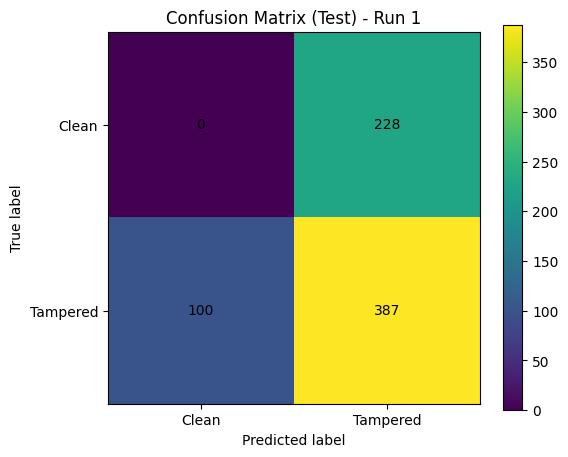


RUN 2/5

=== TRAIN ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[   0 1061]
 [ 417 1853]]
              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00      1061
    Tampered       0.64      0.82      0.71      2270

    accuracy                           0.56      3331
   macro avg       0.32      0.41      0.36      3331
weighted avg       0.43      0.56      0.49      3331


=== VALIDATION ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[  0 227]
 [108 379]]
              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00       227
    Tampered       0.63      0.78      0.69       487

    accuracy                           0.53       714
   macro avg       0.31      0.39      0.35       714
weighted avg       0.43      0.53      0.47       714


=== TEST ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[  0 228]
 [100 387]]
              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00      

,Split,Accuracy,Precision,Recall,F1-score,Specificity (TNR),TN,FP,FN,TP,N_Clean,N_Tampered
0,Train,0.5563,0.6359,0.8163,0.7149,0.0,0,1061,417,1853,1061,2270
1,Validation,0.5308,0.6254,0.7782,0.6935,0.0,0,227,108,379,227,487
2,Test,0.5413,0.6293,0.7947,0.7024,0.0,0,228,100,387,228,487


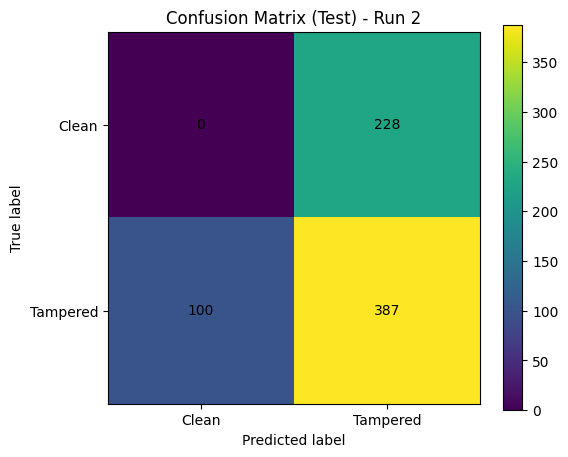


RUN 3/5

=== TRAIN ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[   0 1061]
 [ 417 1853]]
              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00      1061
    Tampered       0.64      0.82      0.71      2270

    accuracy                           0.56      3331
   macro avg       0.32      0.41      0.36      3331
weighted avg       0.43      0.56      0.49      3331


=== VALIDATION ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[  0 227]
 [108 379]]
              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00       227
    Tampered       0.63      0.78      0.69       487

    accuracy                           0.53       714
   macro avg       0.31      0.39      0.35       714
weighted avg       0.43      0.53      0.47       714


=== TEST ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[  0 228]
 [100 387]]
              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00      

,Split,Accuracy,Precision,Recall,F1-score,Specificity (TNR),TN,FP,FN,TP,N_Clean,N_Tampered
0,Train,0.5563,0.6359,0.8163,0.7149,0.0,0,1061,417,1853,1061,2270
1,Validation,0.5308,0.6254,0.7782,0.6935,0.0,0,227,108,379,227,487
2,Test,0.5413,0.6293,0.7947,0.7024,0.0,0,228,100,387,228,487


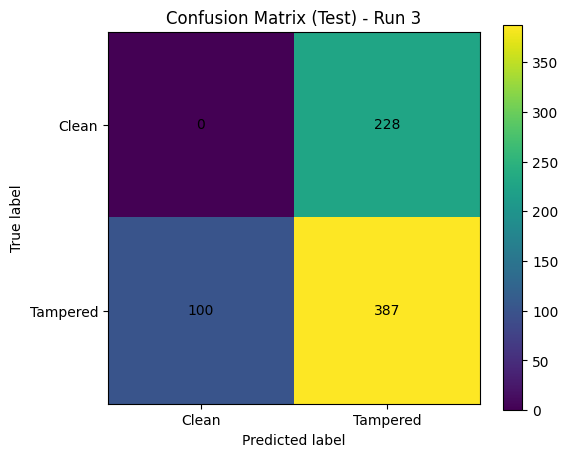


RUN 4/5

=== TRAIN ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[   0 1061]
 [ 417 1853]]
              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00      1061
    Tampered       0.64      0.82      0.71      2270

    accuracy                           0.56      3331
   macro avg       0.32      0.41      0.36      3331
weighted avg       0.43      0.56      0.49      3331


=== VALIDATION ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[  0 227]
 [108 379]]
              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00       227
    Tampered       0.63      0.78      0.69       487

    accuracy                           0.53       714
   macro avg       0.31      0.39      0.35       714
weighted avg       0.43      0.53      0.47       714


=== TEST ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[  0 228]
 [100 387]]
              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00      

,Split,Accuracy,Precision,Recall,F1-score,Specificity (TNR),TN,FP,FN,TP,N_Clean,N_Tampered
0,Train,0.5563,0.6359,0.8163,0.7149,0.0,0,1061,417,1853,1061,2270
1,Validation,0.5308,0.6254,0.7782,0.6935,0.0,0,227,108,379,227,487
2,Test,0.5413,0.6293,0.7947,0.7024,0.0,0,228,100,387,228,487


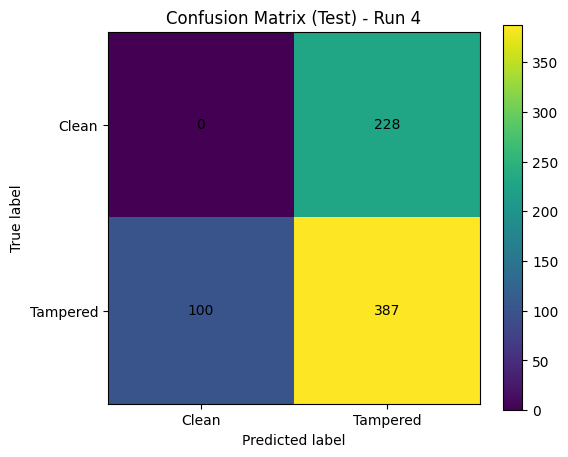


RUN 5/5

=== TRAIN ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[   0 1061]
 [ 417 1853]]
              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00      1061
    Tampered       0.64      0.82      0.71      2270

    accuracy                           0.56      3331
   macro avg       0.32      0.41      0.36      3331
weighted avg       0.43      0.56      0.49      3331


=== VALIDATION ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[  0 227]
 [108 379]]
              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00       227
    Tampered       0.63      0.78      0.69       487

    accuracy                           0.53       714
   macro avg       0.31      0.39      0.35       714
weighted avg       0.43      0.53      0.47       714


=== TEST ===
Confusion Matrix [[TN FP],[FN TP]]:
 [[  0 228]
 [100 387]]
              precision    recall  f1-score   support

       Clean       0.00      0.00      0.00      

,Split,Accuracy,Precision,Recall,F1-score,Specificity (TNR),TN,FP,FN,TP,N_Clean,N_Tampered
0,Train,0.5563,0.6359,0.8163,0.7149,0.0,0,1061,417,1853,1061,2270
1,Validation,0.5308,0.6254,0.7782,0.6935,0.0,0,227,108,379,227,487
2,Test,0.5413,0.6293,0.7947,0.7024,0.0,0,228,100,387,228,487


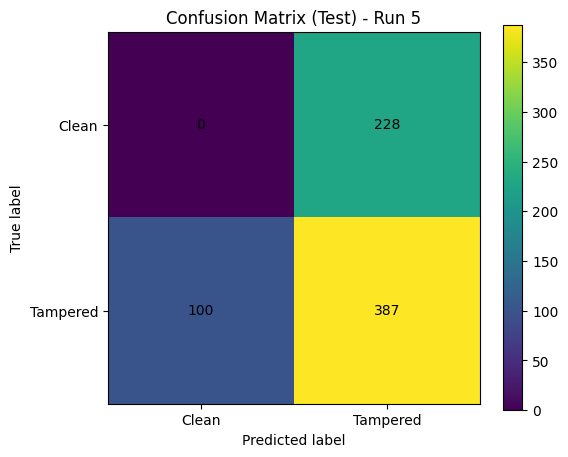


AGGREGATED RESULTS ACROSS RUNS


,Split (Mean),Accuracy,Precision,Recall,F1-score,Specificity (TNR),TN,FP,FN,TP,N_Clean,N_Tampered
0,Test,0.5413,0.6293,0.7947,0.7024,0.0,0.0,228.0,100.0,387.0,228.0,487.0
1,Train,0.5563,0.6359,0.8163,0.7149,0.0,0.0,1061.0,417.0,1853.0,1061.0,2270.0
2,Validation,0.5308,0.6254,0.7782,0.6935,0.0,0.0,227.0,108.0,379.0,227.0,487.0


,Split (Std),Accuracy,Precision,Recall,F1-score,Specificity (TNR),TN,FP,FN,TP,N_Clean,N_Tampered
0,Test,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Train,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Validation,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



AVERAGED CONFUSION MATRIX (TEST) ACROSS RUNS

Average CM (Counts): [[TN FP],[FN TP]]
[[  0. 228.]
 [100. 387.]]

Average CM (Row-normalized rates): [[TN_rate FP_rate],[FN_rate TP_rate]]
[[0.         1.        ]
 [0.20533881 0.79466119]]


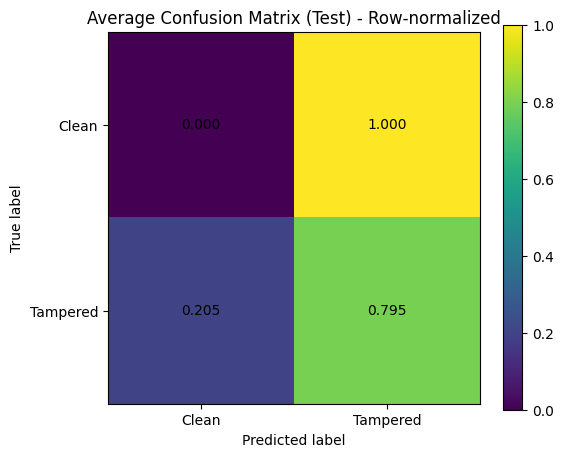

In [46]:
# ManTraNet + LR evaluator 

!pip install -q scikit-learn scikit-image opencv-python numpy joblib tqdm pandas pydicom matplotlib

import os
import numpy as np
import cv2
import joblib
import pandas as pd
from glob import glob
from tqdm import tqdm
import pydicom

from skimage.feature import graycomatrix, graycoprops
from skimage.measure import shannon_entropy

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

from IPython.display import display
import matplotlib.pyplot as plt

# ==========================================
# CHANGE THIS LINE
# ==========================================
TAMPER_SPLIT_DIR = "capstone/testing/splits/BTD_split"
# ==========================================

MODEL_PATH = "capstone/testing/models/mantranet_lr_tamper_detector.joblib"

# Model expects 10 features.
FEATURE_IDX_10 = [0, 1, 4, 5, 6, 7, 8, 9, 10, 11]
N_FEATS = 10

# Unified loader (DICOM + images + NPY) with CT-style normalization
def load_u8_any(path: str, target_size=None):
    ext = os.path.splitext(path)[1].lower()

    # NPY path
    if ext == ".npy":
        try:
            arr = np.load(path)
        except Exception:
            return None

        img = np.squeeze(arr)

        if img.ndim == 3 and img.shape[-1] in (1, 3):
            if img.shape[-1] == 3:
                img = cv2.cvtColor(img.astype(np.float32), cv2.COLOR_BGR2GRAY)
            else:
                img = img[..., 0]
        elif img.ndim == 3 and img.shape[0] in (1, 3):
            if img.shape[0] == 3:
                img = np.transpose(img, (1, 2, 0))
                img = cv2.cvtColor(img.astype(np.float32), cv2.COLOR_BGR2GRAY)
            else:
                img = img[0, :, :]

        if img.ndim != 2:
            return None

        img = img.astype(np.float32)

    # DICOM path
    elif ext == ".dcm":
        try:
            ds = pydicom.dcmread(path, force=True)
            if not hasattr(ds, "PixelData"):
                return None
            img = ds.pixel_array.astype(np.float32)

            if img.ndim == 3:
                img = img[0]

            slope = float(getattr(ds, "RescaleSlope", 1.0))
            intercept = float(getattr(ds, "RescaleIntercept", 0.0))
            img = img * slope + intercept
        except Exception:
            return None

    # Normal image path
    else:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None
        img = img.astype(np.float32)

    if target_size is not None:
        img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA).astype(np.float32)

    lo = np.percentile(img, 1)
    hi = np.percentile(img, 99)
    if hi <= lo:
        hi = lo + 1.0

    img = np.clip(img, lo, hi)
    img = (img - lo) / (hi - lo)

    return (img * 255.0).astype(np.uint8)

# Feature extraction (returns 10 features)
def extract_features(img_u8: np.ndarray) -> np.ndarray:
    if img_u8 is None:
        return None
    if img_u8.ndim != 2:
        img_u8 = cv2.cvtColor(img_u8, cv2.COLOR_BGR2GRAY)

    mean = float(np.mean(img_u8))
    std = float(np.std(img_u8))
    mn = float(np.min(img_u8))
    mx = float(np.max(img_u8))
    median = float(np.median(img_u8))

    edges = cv2.Canny(img_u8, 50, 150)
    edge_density = float(np.mean(edges > 0))

    lap_var = float(cv2.Laplacian(img_u8, cv2.CV_64F).var())
    ent = float(shannon_entropy(img_u8))

    quant = (img_u8 // 16).astype(np.uint8)
    glcm = graycomatrix(
        quant,
        distances=[1, 2],
        angles=[0, np.pi/4, np.pi/2],
        levels=16,
        symmetric=True,
        normed=True
    )

    contrast = float(graycoprops(glcm, "contrast").mean())
    correlation = float(graycoprops(glcm, "correlation").mean())
    energy = float(graycoprops(glcm, "energy").mean())
    homogeneity = float(graycoprops(glcm, "homogeneity").mean())

    feats12 = np.array([
        mean, std, mn, mx, median,
        edge_density, lap_var, ent,
        contrast, correlation, energy, homogeneity
    ], dtype=np.float32)

    feats10 = feats12[FEATURE_IDX_10]
    if feats10.shape[0] != N_FEATS:
        return None
    return feats10

def get_split_files(split_name, class_name):
    exts = ["png","jpg","jpeg","bmp","tif","tiff","dcm","npy"]
    files = []
    for e in exts:
        files += glob(os.path.join(TAMPER_SPLIT_DIR, split_name, class_name, f"*.{e}"))
    return sorted(files)

def build_Xy_from_images(clean_paths, tampered_paths, tag=""):
    X_list, y_list = [], []
    fail_load = 0
    fail_feat = 0

    def _push(p, label):
        nonlocal fail_load, fail_feat
        img_u8 = load_u8_any(p, target_size=None)
        if img_u8 is None:
            fail_load += 1
            return
        feats = extract_features(img_u8)
        if feats is None:
            fail_feat += 1
            return
        feats = np.asarray(feats, dtype=np.float32).reshape(-1)
        if feats.shape[0] != N_FEATS:
            fail_feat += 1
            return
        X_list.append(feats)
        y_list.append(label)

    for p in tqdm(clean_paths, desc=f"{tag} CLEAN feature extraction", unit="img"):
        _push(p, 0)

    for p in tqdm(tampered_paths, desc=f"{tag} TAMPERED feature extraction", unit="img"):
        _push(p, 1)

    # Force proper shapes for sklearn
    if len(X_list) == 0:
        X = np.zeros((0, N_FEATS), dtype=np.float32)
        y = np.zeros((0,), dtype=np.int64)
    else:
        X = np.stack(X_list, axis=0).astype(np.float32)   # (N,10)
        y = np.asarray(y_list, dtype=np.int64)

    print(f"{tag}: kept={X.shape[0]}  failed_load={fail_load}  failed_feat={fail_feat}")
    return X, y

def load_split(split_name):
    clean = get_split_files(split_name, "clean")
    tamp  = get_split_files(split_name, "tampered")
    print(f"\n{split_name.upper()} -> using {len(clean)} clean + {len(tamp)} tampered")
    return build_Xy_from_images(clean, tamp, tag=split_name.upper())

# Load data
X_train, y_train = load_split("train")
X_val, y_val     = load_split("val")
X_test, y_test   = load_split("test")

print("\nShapes:",
      "train", X_train.shape, y_train.shape,
      "| val", X_val.shape, y_val.shape,
      "| test", X_test.shape, y_test.shape)

# Load trained model
model = joblib.load(MODEL_PATH)
print("\nLoaded model:", MODEL_PATH)

# Hard guards
if X_train.shape[0] == 0:
    raise RuntimeError("No usable TRAIN samples produced features. Check split paths / symlinks / decoding.")
if X_train.ndim != 2 or X_train.shape[1] != N_FEATS:
    raise RuntimeError(f"X_train shape is {X_train.shape}, expected (*,{N_FEATS}).")

expected = getattr(model.named_steps["scaler"], "n_features_in_", None)
if expected is None:
    raise RuntimeError("Could not determine expected feature count from model scaler.")
print(f"Model scaler expects {expected} features; built X has {X_train.shape[1]} features.")
if X_train.shape[1] != expected:
    raise RuntimeError(
        f"Feature mismatch: model expects {expected} features but you built {X_train.shape[1]}. "
        f"Adjust FEATURE_IDX_10."
    )

def eval_split(name, X, y):
    if X.shape[0] == 0:
        print(f"\n=== {name} ===\nNo samples in this split after feature extraction.")
        return np.array([], dtype=np.int64)

    preds = model.predict(X)
    print(f"\n=== {name} ===")

    cm = confusion_matrix(y, preds, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()
    print("Confusion Matrix [[TN FP],[FN TP]]:\n", cm)

    if y.sum() == 0:
        fpr = fp / (tn + fp) if (tn + fp) else 0.0
        print(f"False Positive Rate (pred tampered on clean-only): {fpr:.4f}")
        print(f"Specificity / TNR (pred clean on clean-only): {(tn/(tn+fp)):.4f}" if (tn+fp) else "n/a")
        return preds

    print(classification_report(y, preds, target_names=["Clean","Tampered"], zero_division=0))
    return preds

def metrics_row(y_true, y_pred):
    if len(y_true) == 0:
        return {
            "Accuracy": 0.0, "Precision": 0.0, "Recall": 0.0, "F1-score": 0.0, "Specificity (TNR)": 0.0,
            "TN": 0, "FP": 0, "FN": 0, "TP": 0, "N_Clean": 0, "N_Tampered": 0
        }

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    total = tn + fp + fn + tp
    acc = (tn + tp) / total if total else 0.0

    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    tnr  = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "Specificity (TNR)": tnr,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        "N_Clean": int(tn + fp),
        "N_Tampered": int(fn + tp)
    }

# Run N evaluations
N_RUNS = 5
all_runs = []
cms_test_counts = []
cms_test_norm   = []

def run_once(run_id: int):
    print("\n" + "="*60)
    print(f"RUN {run_id+1}/{N_RUNS}")
    print("="*60)

    train_preds = eval_split("TRAIN", X_train, y_train)
    val_preds   = eval_split("VALIDATION", X_val, y_val)
    test_preds  = eval_split("TEST", X_test, y_test)

    metrics_table = pd.DataFrame(
        [metrics_row(y_train, train_preds),
         metrics_row(y_val,   val_preds),
         metrics_row(y_test,  test_preds)],
        index=["Train", "Validation", "Test"]
    ).round(4)

    display(metrics_table.reset_index().rename(columns={"index": "Split"}))

    mt = metrics_table.copy()
    mt["Run"] = run_id + 1
    mt["Split"] = mt.index
    all_runs.append(mt.reset_index(drop=True))

    if len(y_test) == 0 or len(test_preds) == 0:
        return

    cm = confusion_matrix(y_test, test_preds, labels=[0,1])

    cms_test_counts.append(cm.astype(np.float64))
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=np.float64), where=row_sums!=0)
    cms_test_norm.append(cm_norm)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix (Test) - Run {run_id+1}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ["Clean", "Tampered"])
    plt.yticks([0, 1], ["Clean", "Tampered"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.colorbar()
    plt.show()

for r in range(N_RUNS):
    run_once(r)

all_df = pd.concat(all_runs, ignore_index=True)
num_cols = [c for c in all_df.columns if c not in ("Run", "Split")]

summary_mean = all_df.groupby("Split")[num_cols].mean().round(4)
summary_std  = all_df.groupby("Split")[num_cols].std(ddof=0).round(4)

print("\n" + "="*60)
print("AGGREGATED RESULTS ACROSS RUNS")
print("="*60)

display(summary_mean.reset_index().rename(columns={"Split": "Split (Mean)"}))
display(summary_std.reset_index().rename(columns={"Split": "Split (Std)"}))

if len(cms_test_counts) > 0:
    avg_cm_counts = np.mean(np.stack(cms_test_counts, axis=0), axis=0)
    avg_cm_norm   = np.mean(np.stack(cms_test_norm, axis=0), axis=0)

    print("\n" + "="*60)
    print("AVERAGED CONFUSION MATRIX (TEST) ACROSS RUNS")
    print("="*60)

    print("\nAverage CM (Counts): [[TN FP],[FN TP]]")
    print(avg_cm_counts)

    print("\nAverage CM (Row-normalized rates): [[TN_rate FP_rate],[FN_rate TP_rate]]")
    print(avg_cm_norm)

    plt.figure(figsize=(6,5))
    plt.imshow(avg_cm_norm)
    plt.title("Average Confusion Matrix (Test) - Row-normalized")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0,1], ["Clean", "Tampered"])
    plt.yticks([0,1], ["Clean", "Tampered"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, f"{avg_cm_norm[i, j]:.3f}", ha="center", va="center")

    plt.colorbar()
    plt.show()
else:
    print("\nNo TEST confusion matrices accumulated (test split empty after feature extraction).")
